# liquid Xenon TPC inference

In two-phase liquid xenon TPCs, we call the first scintillation signal S1 and the second ionization signal S2. 
In addition to  allowing 3D position reconstruction, the ratio between these two signals carry information about the original interaction. 
We will use the open-source package "alea", developed by the XENON collaboration since it has implemented a very typical likelihood as an example as a 
"statistical model" 






In [27]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
from scipy.optimize import minimize 

from alea import BlueiceExtendedModel, load_yaml
import inference_interface as ii

## Warm-up 

Consider an extended un-binned likelihood $\mathcal L (s,b) = Pois(n|s+b)\times \sum_i\left( \frac s {s+b} Gaus(x_i | 0,1) + \frac b {s+b} Gaus(x_i | 1,1)\right)$ 
where you observe $n$ events and some coordinate $x_i$ for each, with parameters s and b being expectation values for signal and background respectively, and the distribution in $X$ of each being gaussians with standard deviation 1 and means 0 and 1 respectively


 - Write a likelihood representing this model
 - generate some data according to this model
 - Fit the data to the model, does it work?

# A near-complete example of a lXe likelihood

The cell below finds a configuration file in the alea package, and uses it (together with example templates) to construct a similar likelihood for a xenon TPC. 

One important difference: in this case, the likelihood consists of several "terms"-- factors representing successive measurements. 

In this case, these terms represents two different science data sets that in principle might be different.

Alea is installed in /Users/kdund/Software/xenon_software/alea/alea/


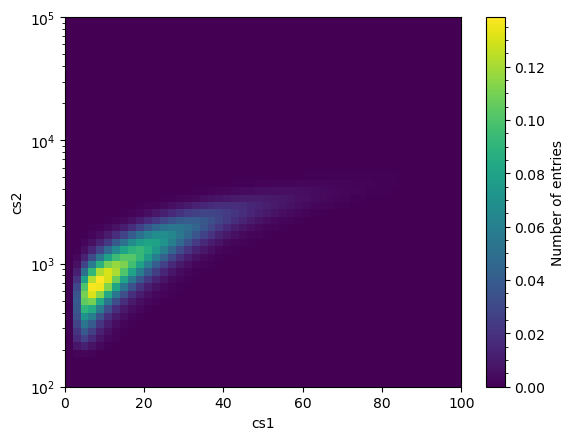

In [32]:
alea_path = alea.__file__.replace("__init__.py","") 
print("Alea is installed in {:s}".format(alea_path))
alea_config_path = alea_path + "/examples/configs/unbinned_wimp_statistical_model.yaml"
alea_template_path = alea_path + "/examples/templates/" #just so you can have a look :) 

wimp_template = alea_template_path + "/wimp50gev_template.ii.h5"
plt.clf()
h_wimp = ii.template_to_multihist(wimp_template)["wimp_template"]
h_wimp.plot()
plt.yscale("log")
plt.show()

In [26]:


config = load_yaml(alea_config_path) #you can modify this config to your liking! 
config["parameter_definition"]["wimp_mass"]["nominal_value"] = 10
model = BlueiceExtendedModel(**config)

Alea is installed in /Users/kdund/Software/xenon_software/alea/alea/
True


Computing/loading models on one core: 100%|███████| 7/7 [00:00<00:00, 97.03it/s]


True


Computing/loading models on one core: 100%|███████| 7/7 [00:00<00:00, 98.77it/s]
/Users/kdund/Software/xenon_software/alea/alea/models/blueice_extended_model.py:711: UserWarning: Uncertainty of er_band_shift is a string-based uncertainty. It is frozen and its argument(s) cannot be changed as ancillary measurement.
  warnings.warn(
building data generators: 100%|██████████████████| 2/2 [00:00<00:00, 208.46it/s]


In [20]:
model.confidence_interval?

Signature:
model.confidence_interval(
    poi_name: str,
    parameter_interval_bounds: Optional[Tuple[float, float]] = None,
    confidence_level: Optional[float] = None,
    confidence_interval_kind: Optional[str] = None,
    confidence_interval_threshold: Optional[Callable[[float], float]] = None,
    confidence_interval_args: Optional[dict] = None,
    best_fit_args: Optional[dict] = None,
    asymptotic_dof: Optional[int] = None,
    fit_strategy: Optional[dict] = None,
) -> Tuple[float, float]
Docstring:
Uses self.fit to compute confidence intervals for a certain named parameter. If the
parameter is a rate parameter, and the model has expectation values implemented, the bounds
will be interpreted as bounds on the expectation value, so that the range in the fit is
parameter_interval_bounds/mus. Otherwise the bound is taken as-is.

Args:
    poi_name (str): name of the parameter of interest
    parameter_interval_bounds (Tuple[float, float], optional (default=None)): range
        

## The statistical model



The alea statistical model is a class with methods to do most things you wish to do with your statistical model, including: 

  - Listing up the parameters of the model
  - generating toy data based on the model
  - evaluating the likelihood for a data set and set of parameters
  - minimizing (fitting) the likelihood to the data
  - computing upper limits 


useful functions: 

  - ```model.generate_data```
  - ```model.fit```
  - ```model.confidence_interval```



# Step 0: Check the documentation! 

Run each of these cells and have a look at the documentation -- using the python introspection is very helpful!



In [21]:
model.generate_data?

Signature: model.generate_data(**kwargs) -> Union[dict, list]
Docstring:
Generate data for the given parameters. The parameters are passed as keyword arguments,
positional arguments are not possible. If a parameter is not given, the default value is
used.

Raises:
    ValueError: If the parameters are not within the fit limits

Returns:
    dict or list: generated data

Caution:
    This implementation won't allow you to call generate_data by positional arguments.
File:      ~/Software/xenon_software/alea/alea/model.py
Type:      method

In [22]:
model.fit?

Signature:
model.fit(
    verbose: Optional[bool] = False,
    fit_strategy: Optional[dict] = None,
    **kwargs,
) -> Tuple[dict, float]
Docstring:
Fit the model to the data by maximizing the likelihood. Return a dict containing best-fit
values of each parameter, and the value of the likelihood evaluated there. While the
optimization is a minimization, the likelihood returned is the __maximum__ of the
likelihood.

Args:
    verbose (bool): if True, print the Minuit object
    fit_strategy (dict): override the default fit strategy defined
        in the model (model.fit_strategy). Possible settings are:
        - minimizer_routine (str): the minimizer routine to use, either
            "migrad", "simplex", or "simplex_migrad" (first run simplex, then migrad).
        - minuit_strategy (int): strategy for Minuit, can be 0, 1, or 2. The higher the
            number, the more precise the fit but also the slower.
        - refit_invalid (bool): if True, refit with the simplex_migrad routi

In [23]:
model.confidence_interval?

Signature:
model.confidence_interval(
    poi_name: str,
    parameter_interval_bounds: Optional[Tuple[float, float]] = None,
    confidence_level: Optional[float] = None,
    confidence_interval_kind: Optional[str] = None,
    confidence_interval_threshold: Optional[Callable[[float], float]] = None,
    confidence_interval_args: Optional[dict] = None,
    best_fit_args: Optional[dict] = None,
    asymptotic_dof: Optional[int] = None,
    fit_strategy: Optional[dict] = None,
) -> Tuple[float, float]
Docstring:
Uses self.fit to compute confidence intervals for a certain named parameter. If the
parameter is a rate parameter, and the model has expectation values implemented, the bounds
will be interpreted as bounds on the expectation value, so that the range in the fit is
parameter_interval_bounds/mus. Otherwise the bound is taken as-is.

Args:
    poi_name (str): name of the parameter of interest
    parameter_interval_bounds (Tuple[float, float], optional (default=None)): range
        

# Step 1: generate data


- Generate some datasets, and plot them in cS1,cS2. Do they look familiar by now? 
- Try setting some parameter values in the data generation, can you make the dataset look different? 


## Step 2: fit data


- Assign the data you generated to the statistical model, and fit your model to the data. Does it make sense?

(Hint-- you can set the data with ```model.data = data```)
- If you do this in a loop and fit 100 times, can you make a distribution of each fitted parameter? 
    - If you set the true signal rate to 0, how does the distribution look then?

### Step 3: Compute asymptotic confidence intervals

use the models confidence interval function to compute confidence intervals-- try doing so 100 times for 0 signal, how does it look? 

#### Step 4: Check coverage
For some true values of the signal, how often does the confidence interval contain this value?

### Step 5: introduce mismodelling

Take a generated dataset, and add in a few far outliers (still covered by your model)-- how are best-fit signals and confidence intervals changed?

## Optional: generate your own ER and NR distributions

The ```appletree``` package is a NEST-like implementation that can generate distributions of ER and NRs. 

https://github.com/XENONnT/appletree



## Optional 2: try making the full model! 


I have included templates for an XLZD projection in a subfolder of this project. 
Try out copying the original likelihood config and adding some of these sources to the data!